In [1]:
# manipulacja danymi
import numpy as np
import pandas as pd

# wizualizacja
import matplotlib.pyplot as plt
import seaborn as sns

# podział danych na zbiory treningowe/walidacyjne/testowe
from sklearn.model_selection import train_test_split, GridSearchCV

# budowa Pipeline
from sklearn.pipeline import FeatureUnion, Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer

# Preprocessing
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures, PowerTransformer

# redukcja wymiarowości
from sklearn.decomposition import PCA

# model
from sklearn.linear_model import LogisticRegression

# ewaluacja
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, f1_score, roc_auc_score

In [3]:
dataset = pd.read_csv('diabetes.csv')
dataset

,PatientID,Pregnancies,PlasmaGlucose,DiastolicBloodPressure,TricepsThickness,SerumInsulin,BMI,DiabetesPedigree,Age,Diabetic
0,1354778,0,171,80,34,23,43.509726,1.213191,21,0
1,1147438,8,92,93,47,36,21.240576,0.158365,23,0
2,1640031,7,115,47,52,35,41.511523,0.079019,23,0
3,1883350,9,103,78,25,304,29.582192,1.282870,43,1
4,1424119,1,85,59,27,35,42.604536,0.549542,22,0
...,...,...,...,...,...,...,...,...,...,...
14995,1490300,10,65,60,46,177,33.512468,0.148327,41,1
14996,1744410,2,73,66,27,168,30.132636,0.862252,38,1
14997,1742742,0,93,89,43,57,18.690683,0.427049,24,0
14998,1099353,0,132,98,18,161,19.791645,0.302257,23,0


In [4]:
X = dataset.drop(['Diabetic', 'PatientID'], axis=1).copy()
y = dataset['Diabetic'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.25, 
    random_state=42, 
    stratify=y
)


In [6]:
num_features = [
    'Pregnancies',
    'PlasmaGlucose',
    'DiastolicBloodPressure',
    'TricepsThickness',
    'SerumInsulin',
    'BMI',
    'DiabetesPedigree',
    'Age'
]


In [7]:
num_preparation = Pipeline(steps=[
    ('fill_missings', SimpleImputer(strategy='mean'))
])


In [8]:
print('Surowy zbiór danych - zbiór treningowy:')
print(X_train[num_features].isnull().mean())

X_train_transformed = num_preparation.fit_transform(X_train[num_features])
X_train_transformed = pd.DataFrame(X_train_transformed, columns=num_features)

print('\nWyjście Pipeline - zbiór treningowy:')
print(X_train_transformed[num_features].isnull().mean())


Surowy zbiór danych - zbiór treningowy:
Pregnancies               0.0
PlasmaGlucose             0.0
DiastolicBloodPressure    0.0
TricepsThickness          0.0
SerumInsulin              0.0
BMI                       0.0
DiabetesPedigree          0.0
Age                       0.0
dtype: float64

Wyjście Pipeline - zbiór treningowy:
Pregnancies               0.0
PlasmaGlucose             0.0
DiastolicBloodPressure    0.0
TricepsThickness          0.0
SerumInsulin              0.0
BMI                       0.0
DiabetesPedigree          0.0
Age                       0.0
dtype: float64


In [10]:
num_features = [
    'Pregnancies',
    'PlasmaGlucose',
    'DiastolicBloodPressure',
    'TricepsThickness',
    'SerumInsulin',
    'BMI',
    'DiabetesPedigree',
    'Age'
]

# przygotowanie wartości numerycznych
num_preparation = Pipeline(steps=[
    ('fill_missings', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

# transformer = wartości numeryczne
data_preparation = ColumnTransformer(transformers=[
    ('numeric_preprocessing', num_preparation, num_features)
])



In [11]:
data_preparation.fit_transform(X_train)

array([[ 1.99624709, -0.21453129,  1.65439606, ..., -0.79990303,
        -0.58391053, -0.75448319],
       [ 1.40705148,  0.25428709,  0.76088209, ...,  0.44837002,
        -0.51935228, -0.75448319],
       [-0.65513314,  0.28554165, -1.08571347, ..., -1.3084427 ,
        -0.63782101, -0.67190528],
       ...,
       [-0.94973095, -0.21453129, -0.66874028, ...,  0.73988437,
        -0.42254369, -0.58932737],
       [-0.65513314,  1.94203324, -0.72830788, ...,  0.50844795,
         0.80167247, -0.58932737],
       [-0.65513314, -1.68349553,  0.4034765 , ..., -1.06039675,
        -0.60701746, -0.67190528]])

In [12]:
class DropPatientID(BaseEstimator, TransformerMixin):
    
    def __init__(self, column='PatientID'):
        self.column = column

    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        X_transformed = X.copy()
        if self.column in X_transformed.columns:
            X_transformed = X_transformed.drop(self.column, axis=1)
        return X_transformed


In [14]:
# Twój custom transformer do usuwania PatientID
drop_id = DropPatientID(column='PatientID')

# Transformacja danych - usunięcie kolumny PatientID
X_train_transformed = drop_id.fit_transform(X_train)

# Wyświetlenie wyniku po transformerze
display(X_train_transformed.head())


,Pregnancies,PlasmaGlucose,DiastolicBloodPressure,TricepsThickness,SerumInsulin,BMI,DiabetesPedigree,Age
10691,10,101,99,45,66,23.625555,0.179501,21
6152,8,116,84,11,55,35.798325,0.203872,21
7016,1,117,53,41,42,18.666434,0.159149,22
8035,3,113,94,24,59,33.038855,0.115565,60
11491,7,138,57,7,237,18.864558,0.241194,23


In [15]:
# Ponieważ nie ma zmiennych kategorycznych, użyjemy tylko pipeline dla numerycznych
print("Przed:")
display(X_train[num_features].head())

print("Po:")
X_train_transformed = num_preparation.fit_transform(X_train[num_features])
X_train_transformed = pd.DataFrame(X_train_transformed, columns=num_features)
display(X_train_transformed.head())


Przed:


,Pregnancies,PlasmaGlucose,DiastolicBloodPressure,TricepsThickness,SerumInsulin,BMI,DiabetesPedigree,Age
10691,10,101,99,45,66,23.625555,0.179501,21
6152,8,116,84,11,55,35.798325,0.203872,21
7016,1,117,53,41,42,18.666434,0.159149,22
8035,3,113,94,24,59,33.038855,0.115565,60
11491,7,138,57,7,237,18.864558,0.241194,23


Po:


,Pregnancies,PlasmaGlucose,DiastolicBloodPressure,TricepsThickness,SerumInsulin,BMI,DiabetesPedigree,Age
0,1.996247,-0.214531,1.654396,1.109729,-0.539475,-0.799903,-0.583911,-0.754483
1,1.407051,0.254287,0.760882,-1.230232,-0.621834,0.448370,-0.519352,-0.754483
2,-0.655133,0.285542,-1.085713,0.834439,-0.719166,-1.308443,-0.637821,-0.671905
3,-0.065938,0.160523,1.356558,-0.335541,-0.591885,0.165396,-0.753275,2.466055
4,1.112454,0.941887,-0.847443,-1.505521,0.740828,-1.288126,-0.420488,-0.589327


In [16]:
# pipeline dla wszystkich kolumn numerycznych
num_preparation = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# zastosowanie pipeline do zbioru treningowego
X_train_transformed = num_preparation.fit_transform(X_train[num_features])
X_train_transformed = pd.DataFrame(X_train_transformed, columns=num_features)
X_train_transformed.head()

,Pregnancies,PlasmaGlucose,DiastolicBloodPressure,TricepsThickness,SerumInsulin,BMI,DiabetesPedigree,Age
0,1.996247,-0.214531,1.654396,1.109729,-0.539475,-0.799903,-0.583911,-0.754483
1,1.407051,0.254287,0.760882,-1.230232,-0.621834,0.448370,-0.519352,-0.754483
2,-0.655133,0.285542,-1.085713,0.834439,-0.719166,-1.308443,-0.637821,-0.671905
3,-0.065938,0.160523,1.356558,-0.335541,-0.591885,0.165396,-0.753275,2.466055
4,1.112454,0.941887,-0.847443,-1.505521,0.740828,-1.288126,-0.420488,-0.589327


In [17]:
# Pipeline dla zmiennych numerycznych
num_preparation = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Ponieważ nie mamy zmiennych kategorycznych, cat_preparation pomijamy
# ColumnTransformer obejmie tylko dane numeryczne
data_preparation = ColumnTransformer(transformers=[
    ('numeric_preprocessing', num_preparation, num_features)
])

In [18]:
# dopasowanie i transformacja danych treningowych
X_train_prepared = data_preparation.fit_transform(X_train)

# dopasowanie danych testowych
X_test_prepared = data_preparation.transform(X_test)

# sprawdzenie kształtu
print("Kształt przetworzonych danych:", X_train_prepared.shape)


Kształt przetworzonych danych: (11250, 8)


In [19]:
# Pełny pipeline z preprocessingiem i modelem
model_pipeline_v1 = Pipeline(steps=[
    ('drop_id', DropPatientID()),       # usuwa PatientID
    ('preprocessor', data_preparation), # preprocessing numeryczny
    ('model', LogisticRegression(max_iter=10000))  # model regresji logistycznej
])

In [21]:
# Podział danych
X = dataset.drop('Diabetic', axis=1)
y = dataset['Diabetic']

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

In [23]:
# Trening modelu
model_pipeline_v1.fit(X_train, y_train)

Pipeline(steps=[('drop_id', DropPatientID()),
                ('preprocessor',
                 ColumnTransformer(transformers=[('numeric_preprocessing',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Pregnancies',
                                                   'PlasmaGlucose',
                                                   'DiastolicBloodPressure',
                                                   'TricepsThickness',
                                                   'SerumInsulin', 'BMI',
                                                   'DiabetesPedigree',
                                                   'Age'])])),
                ('model', LogisticRegression(max_iter=10000))])

In [24]:
# Predykcja
y_pred = model_pipeline_v1.predict(X_test)

In [25]:
print(classification_report(y_test, y_pred))
print("F1 score:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.88      0.85      2500
           1       0.72      0.60      0.65      1250

    accuracy                           0.79      3750
   macro avg       0.77      0.74      0.75      3750
weighted avg       0.78      0.79      0.78      3750

F1 score: 0.6535947712418301
ROC AUC: 0.741


              precision    recall  f1-score   support

           0       0.82      0.88      0.85      2500
           1       0.72      0.60      0.65      1250

    accuracy                           0.79      3750
   macro avg       0.77      0.74      0.75      3750
weighted avg       0.78      0.79      0.78      3750



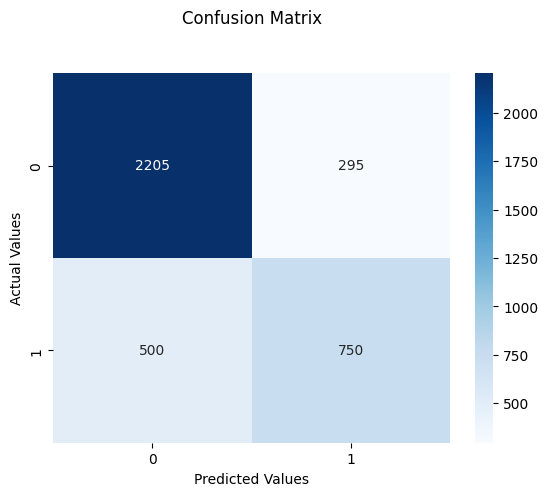

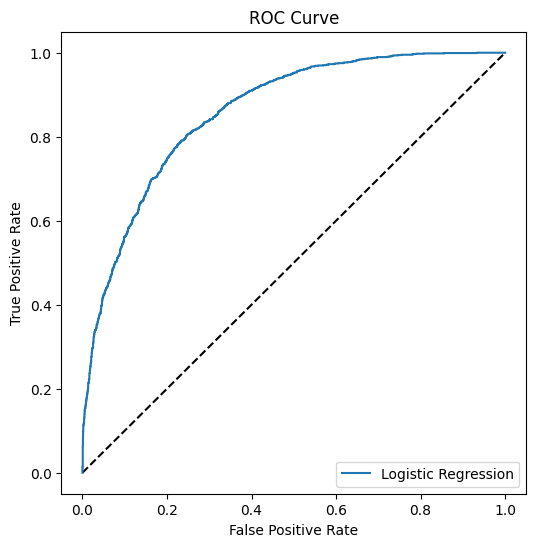

C:\Users\Tomasz\AppData\Local\Temp\ipykernel_19272\1898272738.py:53: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_dataframe = pd.concat(


,Model,F1_score,AUC
0,Logistic Regression,0.653595,0.859497


In [26]:
# przygotowanie pustego DataFrame do metryk
metrics_dataframe = pd.DataFrame(columns=['Model', 'F1_score', 'AUC'])

# listy do przechowywania modeli i predykcji
models = []
models_names = []
predictions_proba_list = []

def calculate_metrics(model, name, X_checked, y_checked):
    models.append(model)
    models_names.append(name)
    global metrics_dataframe

    # predykcje
    predictions = model.predict(X_checked)
    
    # predykcje prawdopodobieństw, jeśli dostępne
    if hasattr(model, "predict_proba"):
        predictions_proba = model.predict_proba(X_checked)[:, 1]
    else:
        predictions_proba = predictions  # fallback dla modeli bez predict_proba
    predictions_proba_list.append(predictions_proba)

    # Classification raport
    print(classification_report(y_checked, predictions))

    # Confusion matrix
    plt.figure()
    cm = confusion_matrix(y_checked, predictions)
    ax = sns.heatmap(cm, annot=True, cmap='Blues', fmt='.0f')
    ax.set_title('Confusion Matrix\n\n')
    ax.set_xlabel('Predicted Values')
    ax.set_ylabel('Actual Values')
    plt.show()

    # ROC curve
    plt.figure(figsize=(6, 6))
    plt.plot([0, 1], [0, 1], 'k--')
    for model_selected, name_selected, pred_proba in zip(models, models_names, predictions_proba_list):
        fpr, tpr, thresholds = roc_curve(y_checked, pred_proba)
        plt.plot(fpr, tpr, label=name_selected)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc='lower right')
    plt.show()

    # F1 score i AUC
    f1_metric = f1_score(y_checked, predictions)
    auc_metric = roc_auc_score(y_checked, predictions_proba)

    # dodanie do DataFrame
    metrics_dataframe = pd.concat(
        [metrics_dataframe, pd.DataFrame({'Model':[name], 'F1_score':[f1_metric], 'AUC':[auc_metric]})],
        ignore_index=True
    )

    return metrics_dataframe

# Wywołanie funkcji dla model_pipeline_v1
metrics_dataframe = calculate_metrics(model_pipeline_v1, 'Logistic Regression', X_test, y_test)
metrics_dataframe

In [27]:
# Lista zmiennych numerycznych
num_features = [
    'Pregnancies',
    'PlasmaGlucose',
    'DiastolicBloodPressure',
    'TricepsThickness',
    'SerumInsulin',
    'BMI',
    'DiabetesPedigree',
    'Age'
]

# Pipeline dla zmiennych numerycznych
num_preparation = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),  # uzupełnianie braków
    ('polynomial_features', PolynomialFeatures(degree=3, include_bias=False)),  # cechy wielomianowe
    ('scaler_1', StandardScaler()),   # pierwsze skalowanie
    ('pca', PCA(n_components=0.95)),  # redukcja wymiarowości 95% wariancji
    ('scaler_2', StandardScaler())    # drugie skalowanie po PCA
])

# ColumnTransformer obejmuje tylko zmienne numeryczne
data_preparation = ColumnTransformer(transformers=[
    ('numeric_preprocessing', num_preparation, num_features)
])

# Pełny pipeline z modelem
model_pipeline_v2 = Pipeline(steps=[
    ('drop_id', DropPatientID()),        # usuwa PatientID
    ('preprocessor', data_preparation), # preprocessing numeryczny
    ('model', LogisticRegression(max_iter=10000))
])

# Dopasowanie modelu
model_pipeline_v2.fit(X_train, y_train)

Pipeline(steps=[('drop_id', DropPatientID()),
                ('preprocessor',
                 ColumnTransformer(transformers=[('numeric_preprocessing',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('polynomial_features',
                                                                   PolynomialFeatures(degree=3,
                                                                                      include_bias=False)),
                                                                  ('scaler_1',
                                                                   StandardScaler()),
                                                                  ('pca',
                                                                   PCA(n_components=0.95)),
                                                                  ('scaler_2',
                                                                   StandardScaler())]),
                                                  ['Pregnancies',
                                                   'PlasmaGlucose',
                                                   'DiastolicBloodPressure',
                                                   'TricepsThickness',
                                                   'SerumInsulin', 'BMI',
                                                   'DiabetesPedigree',
                                                   'Age'])])),
                ('model', LogisticRegression(max_iter=10000))])

              precision    recall  f1-score   support

           0       0.81      0.90      0.85      2500
           1       0.74      0.57      0.64      1250

    accuracy                           0.79      3750
   macro avg       0.77      0.73      0.75      3750
weighted avg       0.78      0.79      0.78      3750



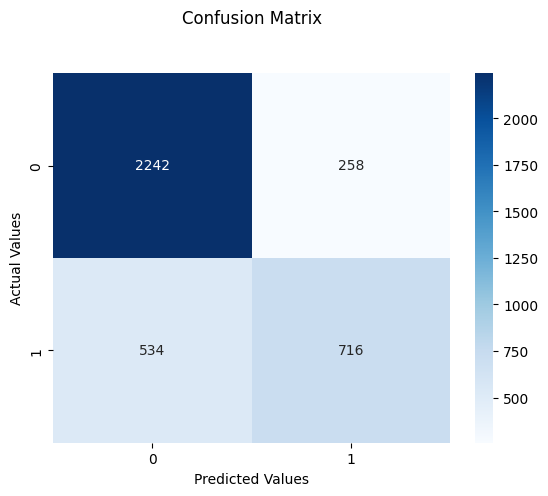

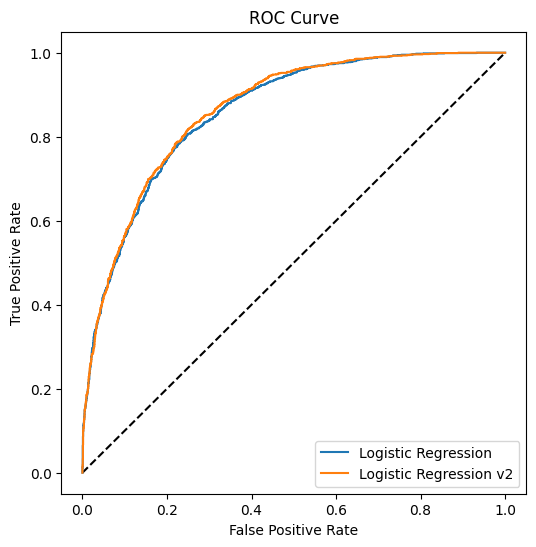

,Model,F1_score,AUC
0,Logistic Regression,0.653595,0.859497
1,Logistic Regression v2,0.643885,0.864158


In [28]:
# Obliczenie metryk dla model_pipeline_v2
metrics_dataframe = calculate_metrics(model_pipeline_v2, 'Logistic Regression v2', X_test, y_test)
metrics_dataframe

In [29]:
# Pełny pipeline (jak v2) – preprocessing + model
model_pipeline_v3 = Pipeline(steps=[
    ('drop_id', DropPatientID()),        # usuwa PatientID
    ('preprocessor', data_preparation),  # preprocessing numeryczny
    ('model', LogisticRegression(max_iter=10000, solver='liblinear'))  # solver dostosowany do małych datasetów
])

# Definicja siatki hiperparametrów do GridSearch
param_grid = {
    'model__C': [0.01, 0.1, 1, 10, 100],          # siła regularizacji
    'model__penalty': ['l1', 'l2'],              # rodzaj regularizacji
    'model__solver': ['liblinear']               # liblinear obsługuje L1 i L2
}

# GridSearchCV – 5-krotna walidacja krzyżowa
grid_search = GridSearchCV(
    estimator=model_pipeline_v3,
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Dopasowanie GridSearch do danych treningowych
grid_search.fit(X_train, y_train)

# Najlepsze parametry i wynik
print("Najlepsze parametry:", grid_search.best_params_)
print("Najlepszy F1 score w CV:", grid_search.best_score_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Najlepsze parametry: {'model__C': 0.1, 'model__penalty': 'l1', 'model__solver': 'liblinear'}
Najlepszy F1 score w CV: 0.6441637736810142


In [30]:
list(model_pipeline_v3.get_params().keys())

['memory',
 'steps',
 'verbose',
 'drop_id',
 'preprocessor',
 'model',
 'drop_id__column',
 'preprocessor__force_int_remainder_cols',
 'preprocessor__n_jobs',
 'preprocessor__remainder',
 'preprocessor__sparse_threshold',
 'preprocessor__transformer_weights',
 'preprocessor__transformers',
 'preprocessor__verbose',
 'preprocessor__verbose_feature_names_out',
 'preprocessor__numeric_preprocessing',
 'preprocessor__numeric_preprocessing__memory',
 'preprocessor__numeric_preprocessing__steps',
 'preprocessor__numeric_preprocessing__verbose',
 'preprocessor__numeric_preprocessing__imputer',
 'preprocessor__numeric_preprocessing__polynomial_features',
 'preprocessor__numeric_preprocessing__scaler_1',
 'preprocessor__numeric_preprocessing__pca',
 'preprocessor__numeric_preprocessing__scaler_2',
 'preprocessor__numeric_preprocessing__imputer__add_indicator',
 'preprocessor__numeric_preprocessing__imputer__copy',
 'preprocessor__numeric_preprocessing__imputer__fill_value',
 'preprocessor__num

In [ ]:

# Definicja siatki hiperparametrów
params = {
    'preprocessor__numeric_preprocessing__imputer__strategy': ['mean', 'median'],
    'preprocessor__numeric_preprocessing__polynomial_features__degree': [1, 2],
    'preprocessor__numeric_preprocessing__pca__n_components': [0.90, 0.95, 0.99],
    'model__C': np.logspace(-4, 4, 6)
}

# GridSearchCV z 10-krotną walidacją krzyżową i scoringiem F1_macro
grid_search = GridSearchCV(
    estimator=model_pipeline_v3,
    param_grid=params,
    cv=5,
    n_jobs=-1,
    verbose=10,
    scoring='f1_macro'
)

# Trenowanie GridSearch
grid_search.fit(X_train, y_train)

# Wyświetlenie najlepszych hiperparametrów
print('Wybrane hiperparametry: ', grid_search.best_params_)

# Zapisanie najlepszego pipeline
model_v3 = grid_search.best_estimator_

In [ ]:
calculate_metrics(model_v3, 'Logistic Regression - wybór hiperparametrów', X_test, y_test)